# 基于机器学习的自然光相对光谱预测与室内照明补偿设计



## 1. 导入库与运行完整流水线

首次运行会生成 `data/`、`models/` 和 `outputs/` 下的成果。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import __version__ as sklearn_version

from src.data_generator import SPECTRUM_COLUMNS, WAVELENGTHS
from src.led_spectrum_data import fetch_and_build_dual_white_spectrum, source_frame
from src.lighting_compensation import (
    band_error_frame,
    channel_recommendation_frame,
    compensation_summary_frame,
    compute_compensation,
)
from src.pipeline import run_full_pipeline
from src.visualization import (
    plot_base_spectrum,
    plot_band_error_reduction,
    plot_channel_contributions,
    plot_channel_weights,
    plot_compensation_result,
    plot_feature_importance,
    plot_hourly_lux,
    light_color_comparison_frame,
    plot_light_halo_comparison,
    plot_model_compare,
    plot_pca_variance,
    plot_prediction_compare,
    plot_weather_spectrum_compare,
)

print(f"scikit-learn 版本: {sklearn_version}")
dataset, result = run_full_pipeline(n_samples=1800, seed=42)
print(f"数据集样本数: {len(dataset)}")
print(f"最佳模型: {result.best_model_name}")

scikit-learn 版本: 1.7.2


数据集样本数: 5664
最佳模型: Random Forest


### 1.1 数据自动化获取与气象对齐机制

本项目的核心特色之一是使用**纯 Python 代码实现了数据的自动化拉取与气象回溯对齐**，无需任何手动操作。
数据获取流程主要由以下模块负责：
1. **[real_data_pipeline.py](src/real_data_pipeline.py)**：负责连接 Zenodo 数据库接口，使用  块式下载 78.5MB 的实测天光光谱文件  以及各观测站元数据。并使用  对原始 1nm 步长的光谱进行插值，重采样为 10nm 采样间距。
2. **[weather_api.py](src/weather_api.py)**：接收各观测站的经纬度和时间，利用 Python 对 Open-Meteo REST API 发起 GET 请求，拉取实测时间段的历史小时天气数据（包含云量、湿度、温度、降水），并在本地创建持久化缓存，防止重复请求。

如果检测到本地  文件不存在，流水线会自动调用上述脚本完成完整的数据链构建。

下面我们读取并预览下载的实测天光观测站元数据，展示光谱数据的具体物理采集点位置：


In [2]:
# 预览下载的实测天光观测站元数据
import pandas as pd
loc_meta = pd.read_csv("data/external/meta_location.csv")
display(loc_meta[["location_code", "location_name", "country", "latitude", "longitude", "timezone"]])


,location_code,location_name,country,latitude,longitude,timezone
0,CN-PKX,Beijing,China,39.75 N,116.96 E,Asia/Shanghai
1,DE-BLN,Berlin,Germany,52.51 N,13.33 E,Europe/Berlin
2,ES-UGR,Granada,Spain,37.18 N,3.62 W,Europe/Madrid
3,FR-VLX,Vaulx-en-Velin,France,45.78 N,4.93 E,Europe/Paris
4,SG-SIN,Singapore,Singapore,1.21 N,103.82 E,Asia/Singapore


## 2. 数据集基本信息

In [3]:
display(dataset.head())
print(dataset[['weather', 'scene']].value_counts().head(10))
print(dataset[['cloud_cover', 'humidity', 'solar_altitude', 'outdoor_lux']].describe())

,sample_id,date,hour,city,location_code,weather,cloud_cover,humidity,temperature,precipitation,...,wavelength_780,scene,target_lux,recommended_channel_1,recommended_channel_2,recommended_channel_3,recommended_channel_4,recommended_channel_5,recommended_channel_6,recommended_channel_7
0,1,2016-03-16,8,巴黎,FR-VLX,阴,0.81,0.84,2.1,0.0,...,0.05133,办公,450,0.8935,0.6965,0.5427,0.0040,0.6613,0.4543,0.004
1,2,2016-03-16,8,巴黎,FR-VLX,阴,0.81,0.84,2.1,0.0,...,0.05530,阅读,400,0.8421,0.6637,0.5450,0.0040,0.7147,0.4625,0.004
2,3,2016-03-16,8,巴黎,FR-VLX,阴,0.81,0.84,2.1,0.0,...,0.05873,办公,450,0.8891,0.6920,0.5399,0.0040,0.6571,0.4517,0.004
3,4,2016-03-16,8,巴黎,FR-VLX,阴,0.81,0.84,2.1,0.0,...,0.06235,办公,450,0.8868,0.6902,0.5385,0.0040,0.6553,0.4505,0.004
4,5,2016-03-16,8,巴黎,FR-VLX,阴,0.81,0.84,2.1,0.0,...,0.06566,学习,500,0.9134,0.7007,0.5580,0.0422,0.6546,0.3892,0.004


weather  scene
晴        学习       1216
         阅读        939
         办公        642
雨        学习        573
         阅读        525
         办公        366
晴        休息        359
阴        学习        197
雨        休息        193
阴        阅读        144
Name: count, dtype: int64
       cloud_cover     humidity  solar_altitude    outdoor_lux
count  5664.000000  5664.000000     5664.000000    5664.000000
mean      0.415429     0.719017       36.357768   41145.126412
std       0.456162     0.195160       14.758781   29368.210736
min       0.000000     0.360000       15.000000    1719.000000
25%       0.000000     0.550000       21.900000   13467.500000
50%       0.090000     0.770000       36.500000   33600.000000
75%       1.000000     0.900000       43.800000   67380.000000
max       1.000000     0.990000       70.000000  101000.000000


## 3. 标准日光与天气光谱可视化

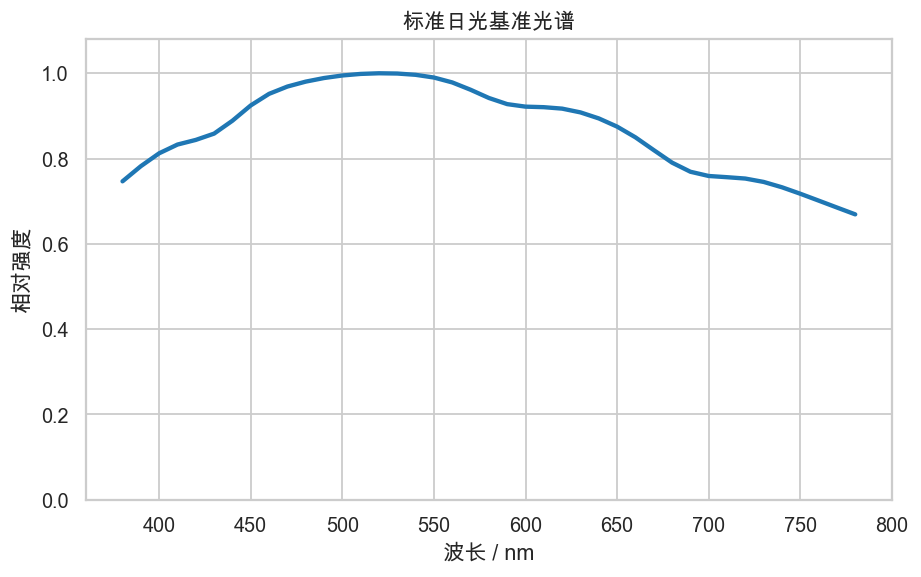

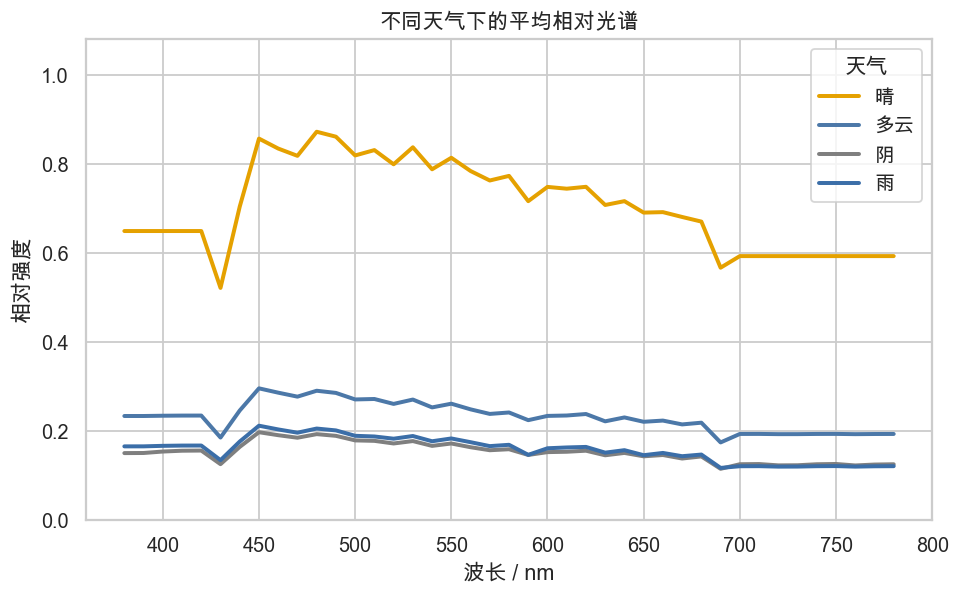

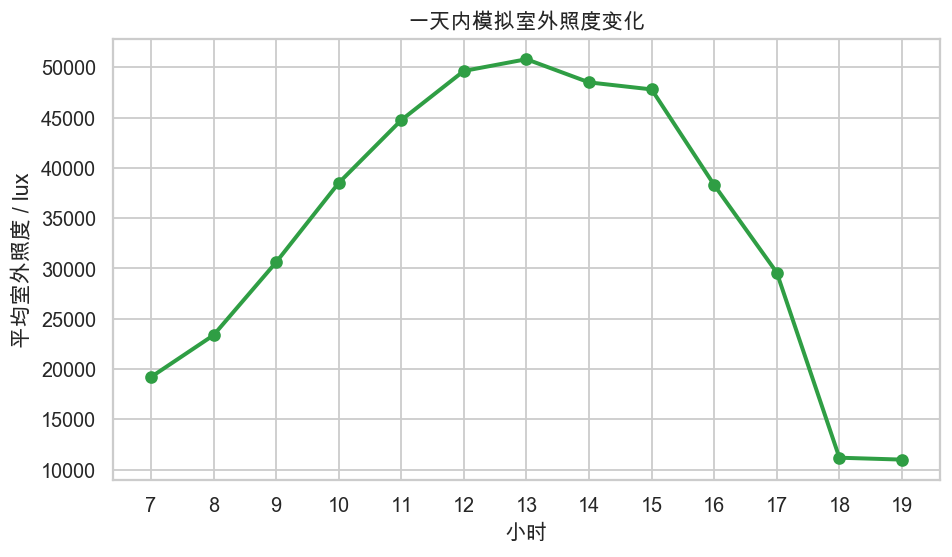

In [4]:
base_df = pd.read_csv('data/base_spectrum.csv', encoding='utf-8-sig')
plot_base_spectrum(base_df)
plt.show()

plot_weather_spectrum_compare(dataset)
plt.show()

plot_hourly_lux(dataset)
plt.show()

## 4. PCA 光谱降维结果

`result.pca` 来自 `sklearn.decomposition.PCA`，下表展示 sklearn PCA 输出的解释方差比例与累计解释方差。

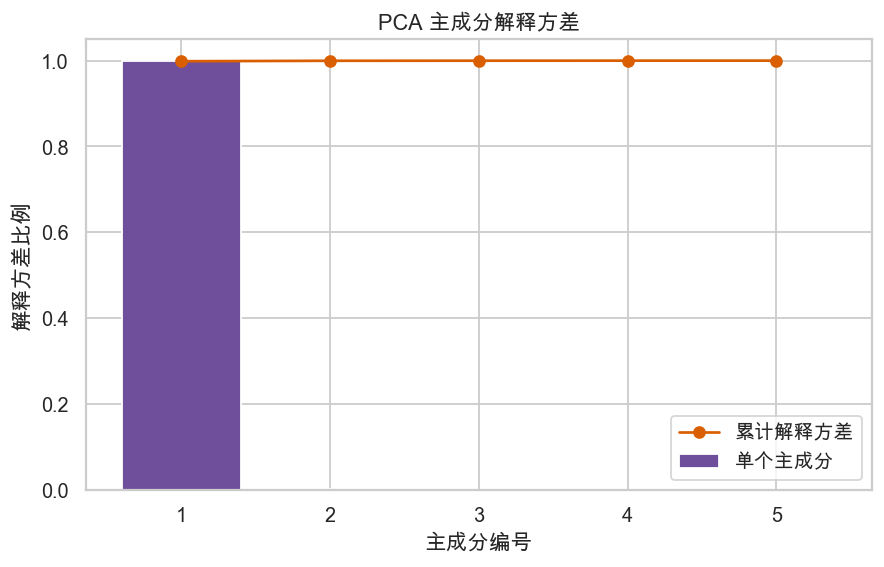

,component,explained_variance_ratio,cumulative_variance_ratio
0,1,0.998586,0.998586
1,2,0.001042,0.999628
2,3,0.000192,0.999820
3,4,0.000124,0.999944
4,5,0.000032,0.999976


In [5]:
plot_pca_variance(result.pca)
plt.show()

pca_table = pd.DataFrame({
    'component': np.arange(1, len(result.pca.explained_variance_ratio_) + 1),
    'explained_variance_ratio': result.pca.explained_variance_ratio_,
    'cumulative_variance_ratio': np.cumsum(result.pca.explained_variance_ratio_),
})
display(pca_table)

## 5. 多模型训练与评价

,model,MAE,RMSE,R2
0,Random Forest,0.002795,0.005759,0.999727
1,KNN Regression,0.003044,0.007621,0.999547
2,Decision Tree,0.003291,0.011678,0.998800
3,Linear Regression,0.037130,0.045748,0.984109


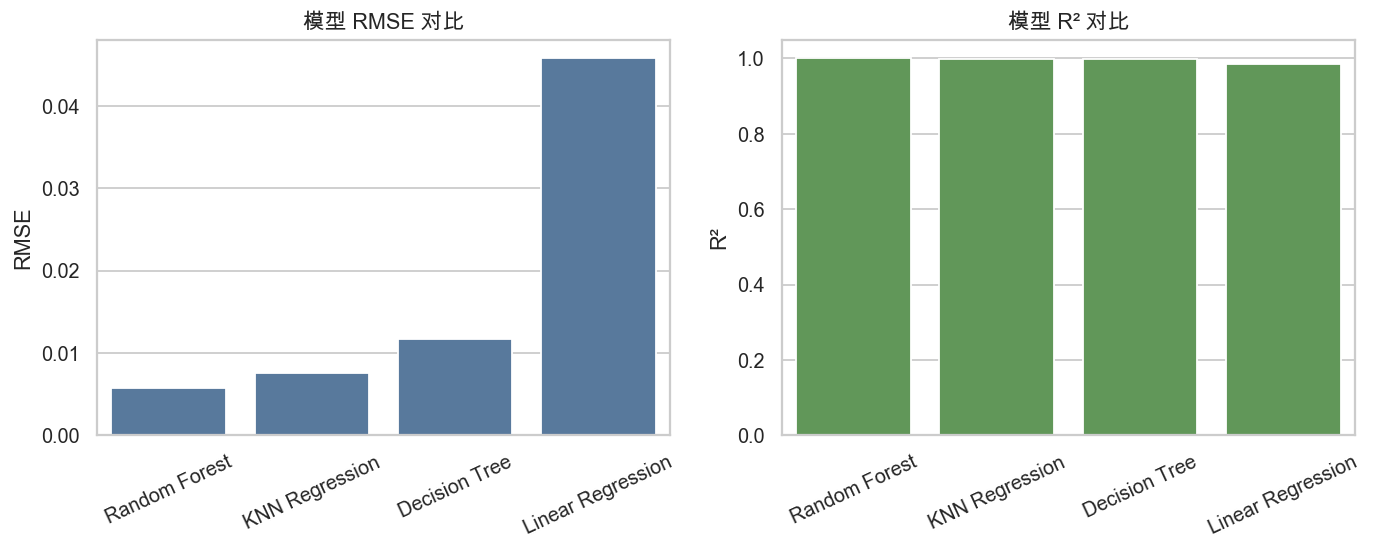

,feature,importance
0,outdoor_lux,0.965674
1,hour,0.012282
2,humidity,0.007755
3,temperature,0.007599
4,solar_altitude,0.004980
5,weather,0.000849
6,cloud_cover,0.000753
7,precipitation,0.000107


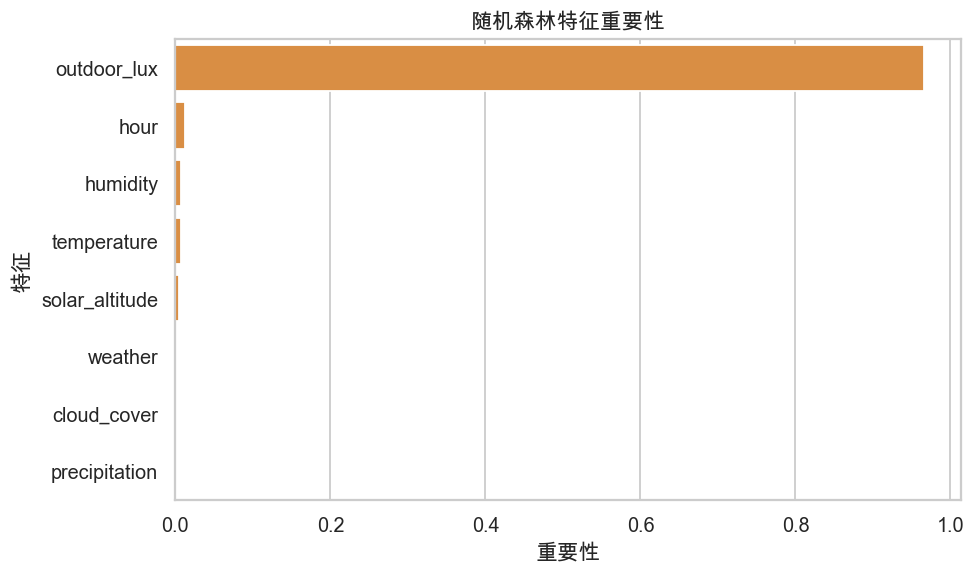

In [6]:
display(result.metrics)
plot_model_compare(result.metrics)
plt.show()

display(result.feature_importance)
plot_feature_importance(result.feature_importance)
plt.show()

## 6. 光谱预测还原效果

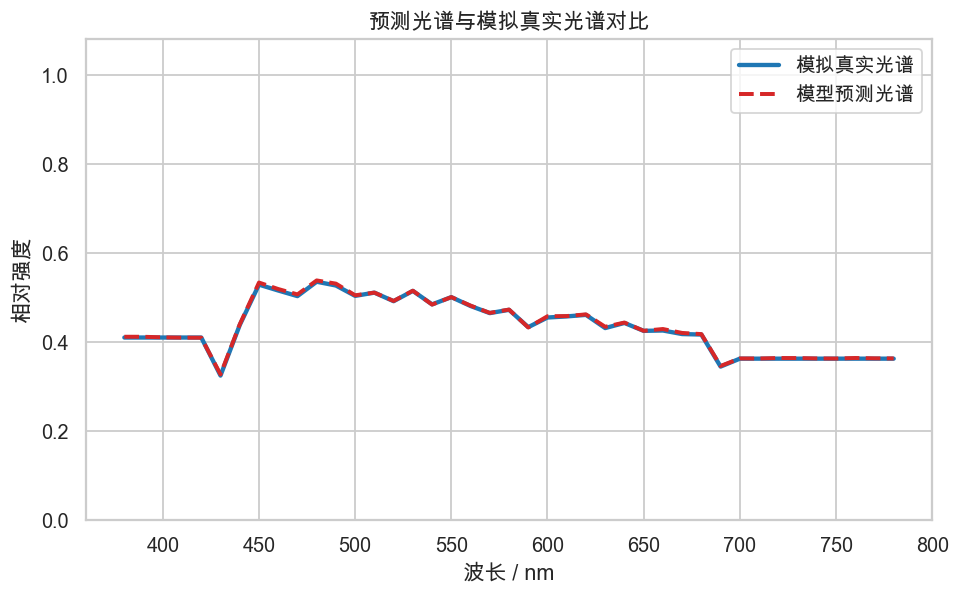

,date,hour,weather,cloud_cover,humidity,solar_altitude,outdoor_lux,scene,target_lux
5260,2016-09-29,16,晴,0.0,0.37,29.3,47400.0,阅读,400


In [7]:
sample_position = 0
true_spectrum = result.y_test_spectrum[sample_position]
pred_spectrum = result.y_pred_spectrum[sample_position]
plot_prediction_compare(true_spectrum, pred_spectrum)
plt.show()

original_index = int(result.test_indices[sample_position])
display(dataset.loc[[original_index], ['date', 'hour', 'weather', 'cloud_cover', 'humidity', 'solar_altitude', 'outdoor_lux', 'scene', 'target_lux']])

## 7. 外部实测 LED 光谱数据获取

传统双色温灯具不是凭 RGB 颜色直接混出来的，而是由两路白光 LED 的光谱功率分布相加得到。这里使用 Python 下载公开实测 LED SPD CSV，并参考 2700K/6500K 可调白 LED 的常见双通道结构，生成本项目用于对照实验的暖白与冷白通道光谱。

说明：公开 CSV 提供的是商业 LED 实测光谱样本；本项目从中选取蓝光泵浦和宽谱荧光粉型样本，构造课程设计层面的普通双白 LED 光谱近似。它比直接用颜色值模拟更接近真实混光流程。


,用途,来源,链接,说明
0,实测 LED 光谱 CSV,"Harald Brendel, Spectral Power Distribution of...",https://haraldbrendel.com/ledspd.html,29 个商业 LED 的实测 SPD，CSV 覆盖 350-700nm；本项目取蓝光泵浦和宽...
1,双色温灯具结构参考,Bridgelux/L1C1 Vesta tunable white datasheet,https://www.digikey.com/en/htmldatasheets/prod...,公开 datasheet 展示 2700K 到 6500K 可调白 LED 的常见双通道结构...


,wavelength_nm,warm_2700k,cool_6500k
0,380,0.000000,0.000000
1,390,0.000018,0.000010
2,400,0.003745,0.001791
3,410,0.007904,0.006191
4,420,0.040344,0.029641


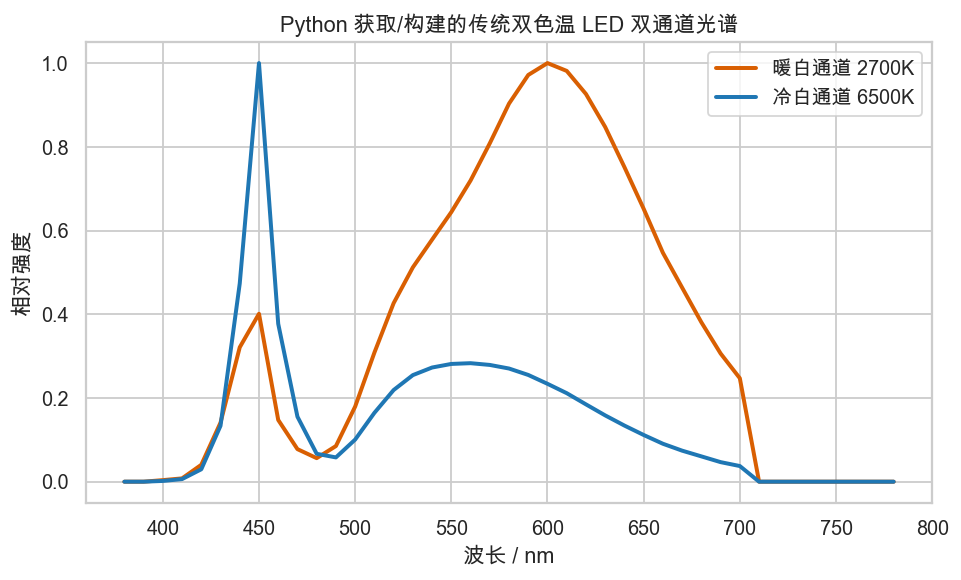

In [8]:
dual_white_df = fetch_and_build_dual_white_spectrum(force=False)
display(source_frame())
display(dual_white_df.head())

plt.figure(figsize=(8.4, 4.6))
plt.plot(dual_white_df['wavelength_nm'], dual_white_df['warm_2700k'], label='暖白通道 2700K', linewidth=2.2, color='#d95f02')
plt.plot(dual_white_df['wavelength_nm'], dual_white_df['cool_6500k'], label='冷白通道 6500K', linewidth=2.2, color='#1f77b4')
plt.title('Python 获取/构建的传统双色温 LED 双通道光谱')
plt.xlabel('波长 / nm')
plt.ylabel('相对强度')
plt.legend()
plt.show()


## 8. 室内七通道 LED 光谱补偿

这一部分不只输出少数几个 LED 比例，而是展示七通道混光系统如何把“预测自然光 + 人工补偿光”拉近到目标光谱。补偿算法保留七个 LED 通道的小比例参与，同时用白光通道提供基础照度、窄带彩色通道负责不同波段的精细修正。本节的传统双色温对照不再直接调 RGB 颜色，而是使用上一节获取/构建的 2700K 暖白和 6500K 冷白光谱真实相加，再统一映射到显示颜色。


典型补偿场景: 学习空间，目标照度 500 lux，室外照度 50000 lux
补偿实验核心指标


,指标,结果
0,自然光占比,0.40
1,有效 LED 通道数,7 / 7
2,补偿前 RMSE,0.5240
3,补偿后 RMSE,0.2416
4,误差下降,53.9%


七通道 LED 输出比例与光谱作用


,通道,峰值波长/nm,推荐比例,输出百分比,光谱作用
0,深蓝/蓝光,445,0.6208,62.1%,补足短波蓝光，影响清醒度和冷感
1,青光,500,0.4420,44.2%,连接蓝光与绿光，平滑中短波过渡
2,绿光,540,0.4087,40.9%,补足视觉敏感区，提高显色稳定性
3,琥珀光,595,0.0769,7.7%,补足黄橙段，改善暖色物体还原
4,红光,635,0.4578,45.8%,补足长波红光，提升暖色与肤色表现
5,暖白,560,0.1790,17.9%,提供暖白基础照度，覆盖黄红连续光谱
6,冷白,505,0.0040,0.4%,提供冷白基础照度，覆盖蓝绿连续光谱


不同波段补偿前后误差对比


,波段,补偿前RMSE,补偿后RMSE,改善幅度
0,短波蓝光 (380-480nm),0.5420,0.2828,47.8%
1,青绿过渡 (480-540nm),0.6149,0.0623,89.9%
2,黄绿敏感区 (540-590nm),0.5952,0.0668,88.8%
3,橙红暖色 (590-680nm),0.5148,0.0916,82.2%
4,深红边缘 (680-780nm),0.4114,0.3590,12.7%


太阳光、预测补偿混光与传统双色温混光颜色对比


,光状态,显示色,相对光谱RMSE
0,目标太阳光,#F8FFFE,0.0000
1,预测补偿混光,#F2FFF2,0.2416
2,传统双色温混光,#FFE2C7,0.3232


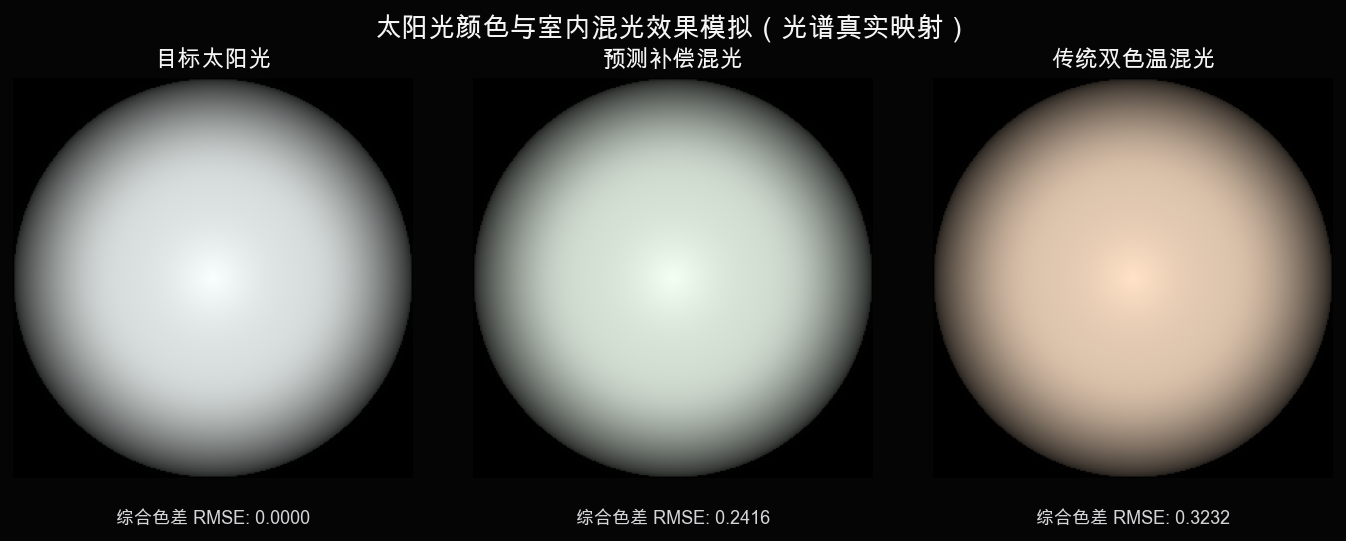

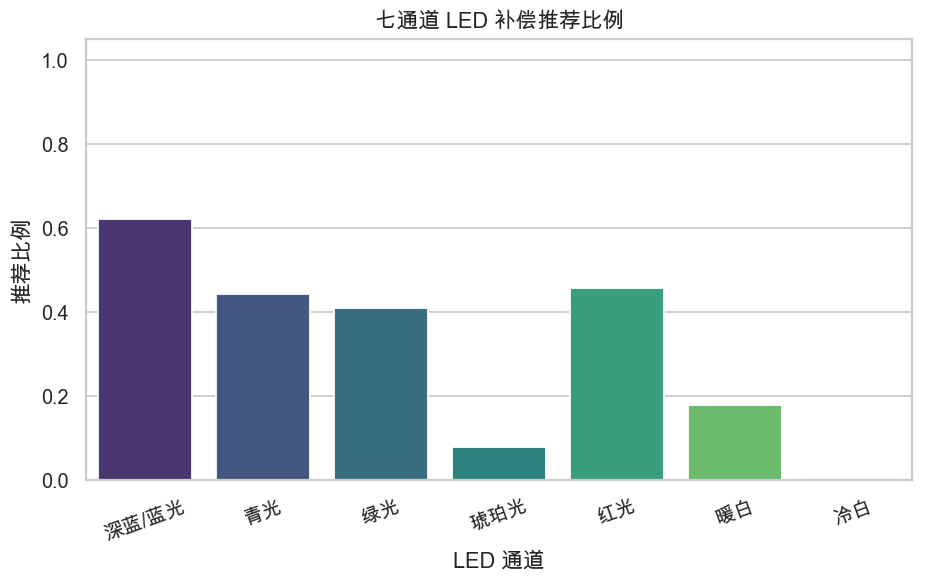

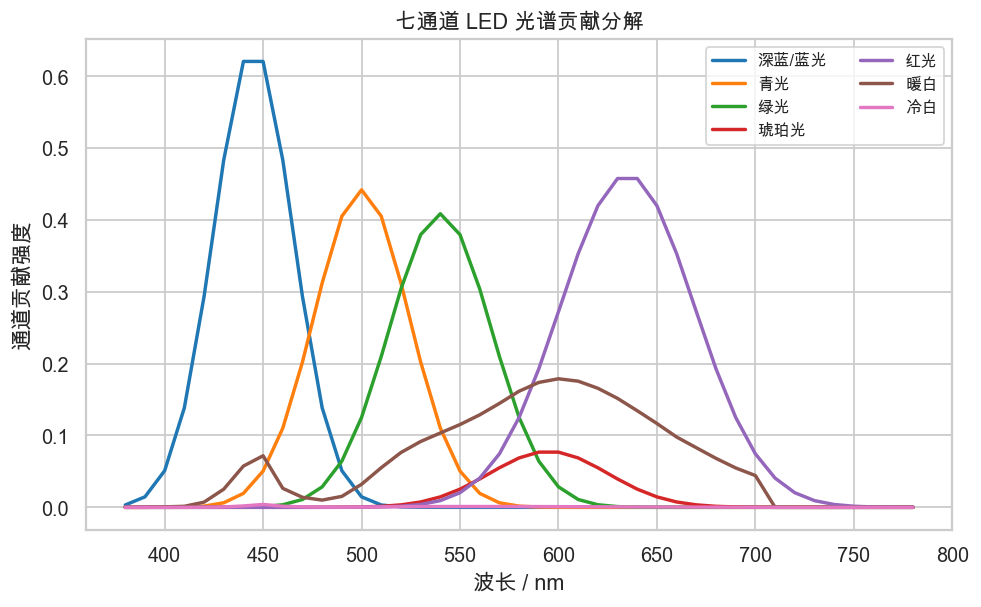

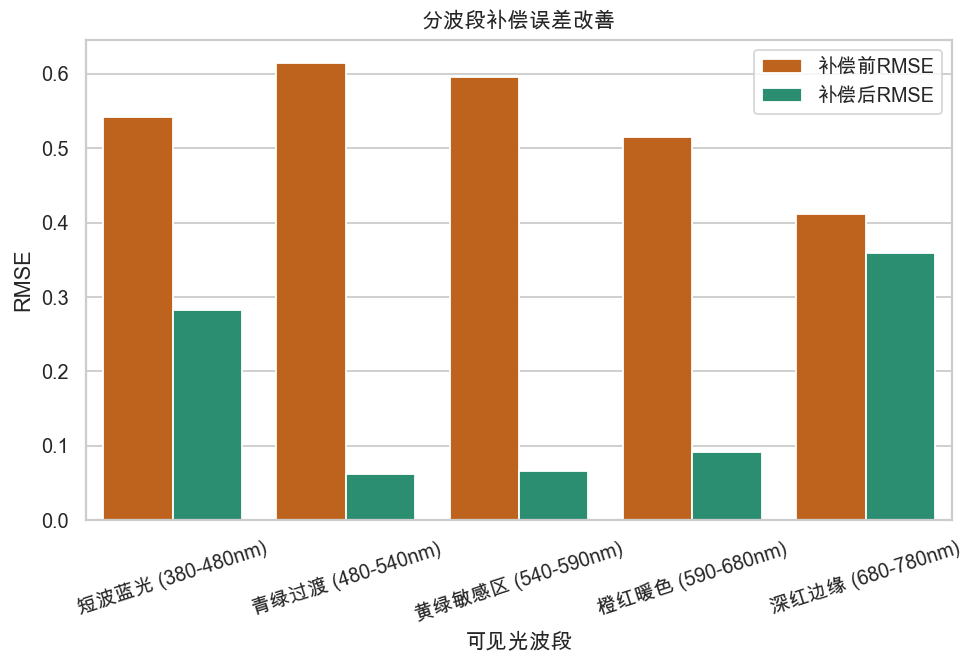

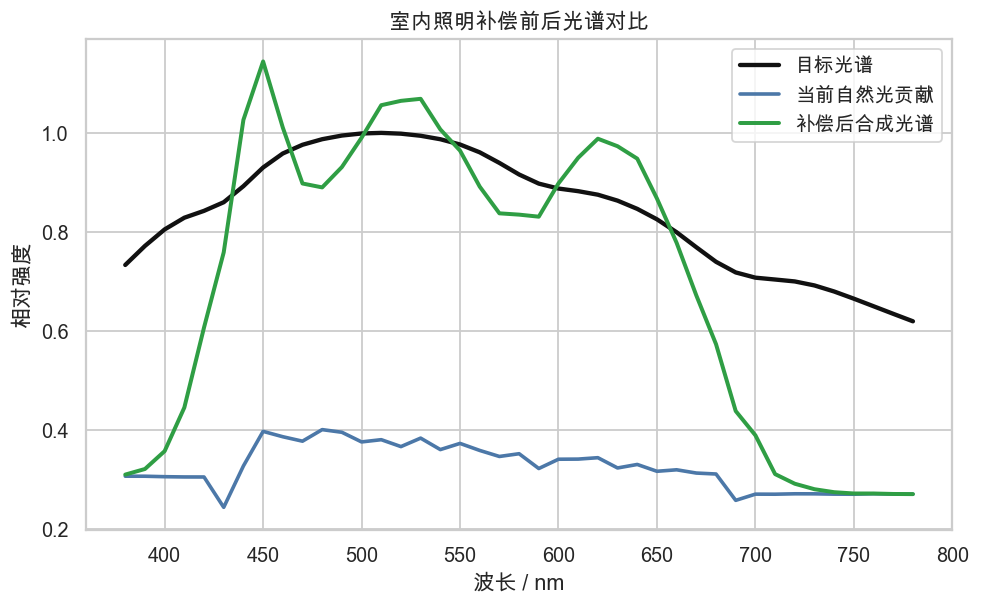

In [9]:
demo_scene = '学习'
demo_target_lux = 500.0
demo_outdoor_lux = 50000.0
compensation = compute_compensation(
    current_spectrum=pred_spectrum,
    scene=demo_scene,
    target_lux=demo_target_lux,
    outdoor_lux=demo_outdoor_lux,
)

print(f'典型补偿场景: {demo_scene}空间，目标照度 {demo_target_lux:.0f} lux，室外照度 {demo_outdoor_lux:.0f} lux')
print('补偿实验核心指标')
display(compensation_summary_frame(compensation))

print('七通道 LED 输出比例与光谱作用')
display(channel_recommendation_frame(compensation.channel_weights))

print('不同波段补偿前后误差对比')
display(band_error_frame(compensation))

print('太阳光、预测补偿混光与传统双色温混光颜色对比')
display(light_color_comparison_frame(compensation))

plot_light_halo_comparison(compensation)
plt.show()

plot_channel_weights(compensation.channel_weights)
plt.show()

plot_channel_contributions(compensation)
plt.show()

plot_band_error_reduction(compensation)
plt.show()

plot_compensation_result(compensation)
plt.show()


## 9. 项目总结

